# 1. Introduction
#### Modélisation avec Random Forest — Agrégation mensuelle

**Objectif**

Entraîner un modèle Random Forest sur les données mensuelles produites par le
feature engineering mensuel (`dataset_ml_mensuel.csv`), afin de :
- prédire les quantités de carburant commandées par mois et par station ;
- comparer les résultats avec les modèles ARIMA/SARIMA sur la **même échelle temporelle**.

## 2. Importation des bibliothèques

In [1]:
# IMPORTATION DES BIBLIOTHÈQUES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

pd.set_option('display.max_columns', None)
print("Bibliothèques importées.")


Bibliothèques importées.


L’implémentation s’appuie sur pandas et numpy pour la gestion des données, scikit-learn pour le modèle Random Forest et les indicateurs de performance, et matplotlib pour les visualisations.

## 3. Chargement du dataset mensuel

On charge `dataset_ml_mensuel.csv` — produit par le notebook FE mensuel.
Chaque ligne = 1 mois × 1 station × 1 article.

In [2]:
# CHARGEMENT DU DATASET MENSUEL

df_ml = pd.read_csv("../data/propre/dataset_ml_mensuel.csv", parse_dates=['mois'])

print(f"Dimensions : {df_ml.shape[0]:,} lignes x {df_ml.shape[1]} colonnes")
print(f"Période    : {df_ml['mois'].min().date()} → {df_ml['mois'].max().date()}")
print(f"Stations   : {df_ml['Code Station'].nunique()}")
print(f"Articles   : {df_ml['N° article'].nunique()}")
print()
display(df_ml.head(10))


Dimensions : 5,473 lignes x 24 colonnes
Période    : 2021-01-01 → 2025-12-01
Stations   : 89
Articles   : 2



,Code Station,N° article,mois_periode,quantite_mois,nb_commandes,mois,annee,num_mois,trimestre,mois_sin,mois_cos,est_t1,est_t4,saison_benin,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,StationEncoded,ProduitEncoded
0,ST0001,A0001,2023-10,79000,4,2023-10-01,2023,10,4,-8.660254e-01,5.000000e-01,0,1,3,20000.0,95000.0,20000.0,65000.000000,68833.333333,57166.666667,39686.269666,1.1370,0,0
1,ST0001,A0001,2023-11,70000,4,2023-11-01,2023,11,4,-5.000000e-01,8.660254e-01,0,1,3,79000.0,80000.0,24000.0,59666.666667,74000.000000,62083.333333,34355.979586,0.9611,0,0
2,ST0001,A0001,2023-12,55000,4,2023-12-01,2023,12,4,-2.449294e-16,1.000000e+00,0,1,0,70000.0,20000.0,49000.0,56333.333333,68166.666667,65916.666667,31785.741038,0.8546,0,0
3,ST0001,A0001,2024-01,55000,5,2024-01-01,2024,1,1,5.000000e-01,8.660254e-01,1,0,0,55000.0,79000.0,56000.0,68000.000000,66500.000000,66416.666667,12124.355653,1.0238,0,0
4,ST0001,A0001,2024-02,105000,7,2024-02-01,2024,2,1,8.660254e-01,5.000000e-01,1,0,0,55000.0,70000.0,34000.0,60000.000000,59833.333333,66333.333333,8660.254038,0.9045,0,0
5,ST0001,A0001,2024-03,87000,5,2024-03-01,2024,3,1,1.000000e+00,6.123234e-17,1,0,1,105000.0,55000.0,90000.0,71666.666667,64000.000000,72250.000000,28867.513459,0.9919,0,0
6,ST0001,A0001,2024-04,93000,5,2024-04-01,2024,4,2,8.660254e-01,-5.000000e-01,0,0,1,87000.0,55000.0,48000.0,82333.333333,75166.666667,72000.000000,25324.559884,1.1435,0,0
7,ST0001,A0001,2024-05,143000,9,2024-05-01,2024,5,2,5.000000e-01,-8.660254e-01,0,0,2,93000.0,105000.0,105000.0,95000.000000,77500.000000,75750.000000,9165.151390,1.2541,0,0
8,ST0001,A0001,2024-06,103000,8,2024-06-01,2024,6,2,1.224647e-16,-1.000000e+00,0,0,2,143000.0,87000.0,65000.0,107666.666667,89666.666667,78916.666667,30746.273487,1.3643,0,0
9,ST0001,A0001,2024-07,96000,7,2024-07-01,2024,7,3,-5.000000e-01,-8.660254e-01,0,0,2,103000.0,93000.0,95000.0,113000.000000,97666.666667,82083.333333,26457.513111,1.3766,0,0


In [5]:
# ==========================================================
# Filtrage des couples ayant au moins 12 mois
# ==========================================================

nb_mois = (
    df_ml
    .groupby(["Code Station", "N° article"])
    .size()
    .reset_index(name="nb_mois")
)

couples_valides = nb_mois[
    nb_mois["nb_mois"] >= 12
][["Code Station", "N° article"]]

df_ml = (
    df_ml.merge(
        couples_valides,
        on=["Code Station", "N° article"],
        how="inner"
    )
)

print("Nombre de couples :", len(couples_valides))
print("Nombre de lignes :", len(df_ml))

Nombre de couples : 147
Nombre de lignes : 5338


In [7]:
df_gasoil = df_ml[
    df_ml["N° article"] == "A0002"
].copy()

Distribution de quantite_mois :
count       2758.0
mean       33068.0
std        38869.0
min         1000.0
25%        15000.0
50%        23000.0
75%        41000.0
max      1078000.0
Name: quantite_mois, dtype: float64



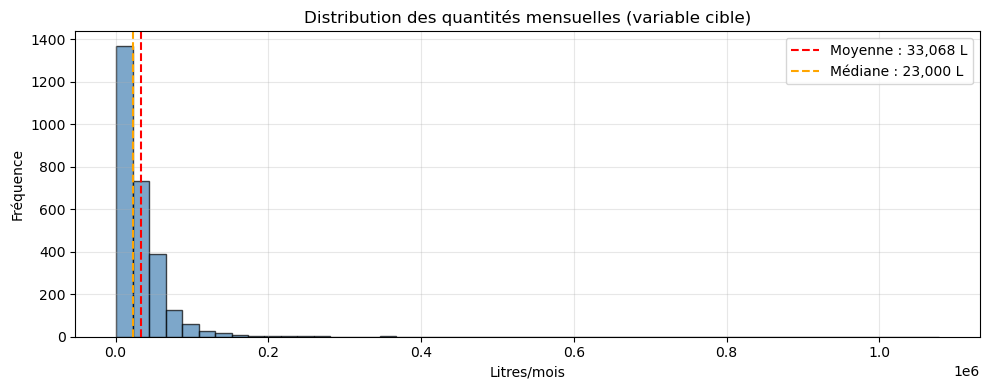

In [9]:
# VÉRIFICATION DE LA VARIABLE CIBLE

print("Distribution de quantite_mois :")
print(df_gasoil['quantite_mois'].describe().round(0))
print()

# Visualisation rapide
plt.figure(figsize=(10, 4))
plt.hist(df_gasoil['quantite_mois'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df_gasoil['quantite_mois'].mean(), color='red', linestyle='--',
            label=f"Moyenne : {df_gasoil['quantite_mois'].mean():,.0f} L")
plt.axvline(df_gasoil['quantite_mois'].median(), color='orange', linestyle='--',
            label=f"Médiane : {df_gasoil['quantite_mois'].median():,.0f} L")
plt.title('Distribution des quantités mensuelles (variable cible)')
plt.xlabel('Litres/mois')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Commentaire du graphique :**
Moyenne : 36 393 L
Médiane : 25 000 L
Écart moyenne - médiane : 11 393 L (la moyenne est nettement supérieure à la médiane)

Cette différence indique une asymétrie droite de la distribution : la queue de distribution s'étend vers les valeurs élevées.

**Interprétation :**

Distribution asymétrique (queue à droite) :
**La moyenne (36 393 L)** étant supérieure à la médiane (25 000 L), cela signifie qu'il existe un nombre non négligeable de mois où les volumes commandés sont très élevés, ce qui tire la moyenne vers le haut. 

Autrement dit :
La moitié des mois affichent des commandes inférieures ou égales à 25 000 L.
L'autre moitié dépasse 25 000 L, avec quelques mois atteignant des volumes très importants.

Concentration sur les faibles volumes :
**La médiane à 25 000 L** suggère que la majorité des observations se situent dans une plage modérée. Les volumes extrêmement élevés sont rares mais influents sur la moyenne.

Implications pour la modélisation :

Un modèle prédictif doit être capable de gérer cette asymétrie : les erreurs de prédiction risquent d'être plus importantes sur les queues de distribution (forts volumes).

Une transformation logarithmique (log) ou une normalisation adaptée (Box-Cox) pourrait améliorer les performances en réduisant l'impact des valeurs extrêmes.

Les métriques d'évaluation sensibles aux outliers (comme l'erreur quadratique moyenne) seront pénalisées par ces quelques mois à très haute consommation.

**Synthèse**
La distribution des volumes mensuels commandés est asymétrique à droite, avec une moyenne (36 393 L) nettement supérieure à la médiane (25 000 L). Cela indique que si la majorité des mois présentent des volumes modérés (≤ 25 000 L), quelques mois affichent des pics de consommation très élevés qui tirent la moyenne vers le haut.

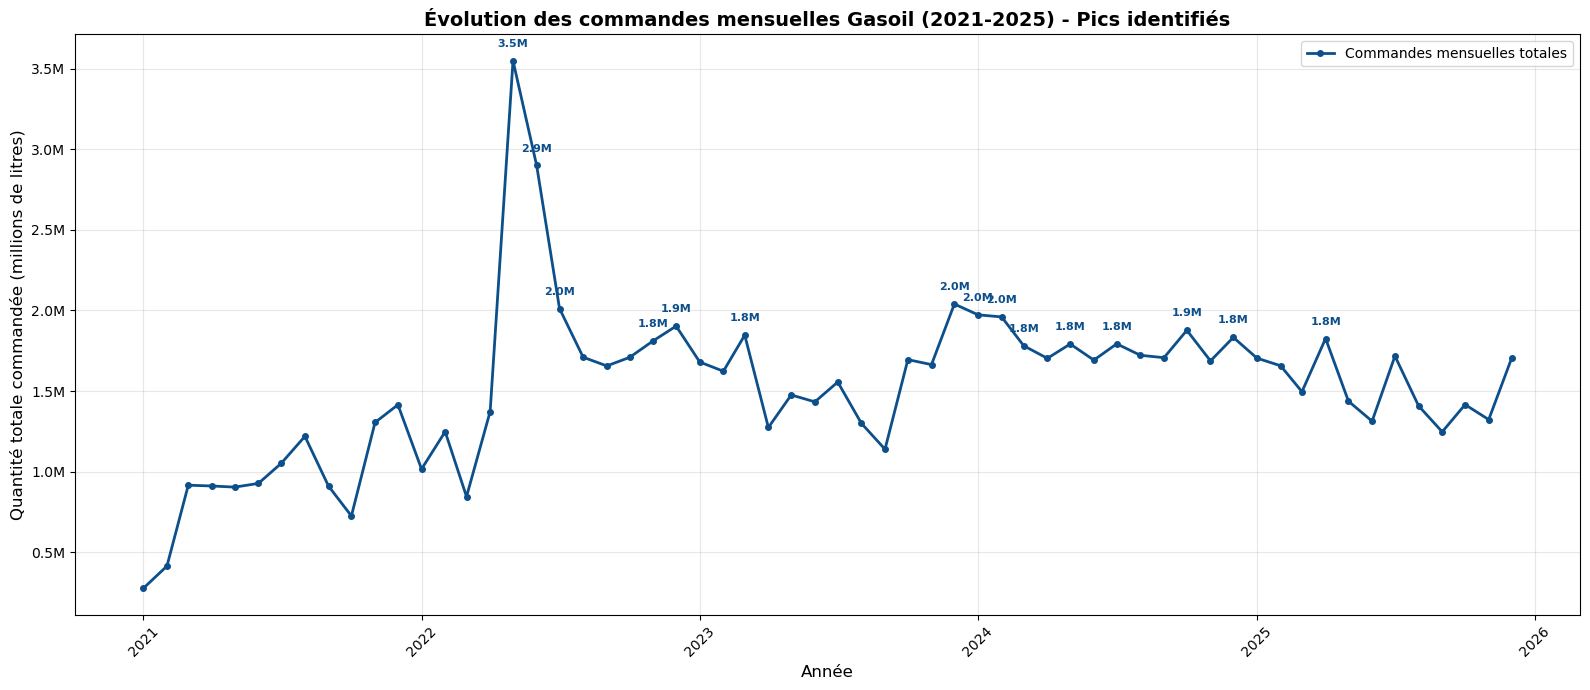

In [11]:
# GRAPHIQUE AVEC ÉTIQUETTES UNIQUEMENT SUR LES PICS

import matplotlib.pyplot as plt

# Agréger les quantités par mois
evolution_mensuelle = df_gasoil.groupby('mois')['quantite_mois'].sum().reset_index()

# Création du graphique
fig, ax = plt.subplots(figsize=(16, 7))

# Tracer la courbe
ax.plot(evolution_mensuelle['mois'], 
        evolution_mensuelle['quantite_mois'], 
        color='#0D4F8B', 
        linewidth=2, 
        marker='o', 
        markersize=4,
        label='Commandes mensuelles totales')

# Identifier les pics (points supérieurs à la moyenne + 0.5 écart-type)
moyenne = evolution_mensuelle['quantite_mois'].mean()
seuil = moyenne + 0.5 * evolution_mensuelle['quantite_mois'].std()

for i, row in evolution_mensuelle.iterrows():
    # Afficher l'étiquette uniquement si c'est un pic
    if row['quantite_mois'] > seuil:
        valeur_millions = row['quantite_mois'] / 1_000_000
        ax.annotate(f'{valeur_millions:.1f}M', 
                    xy=(row['mois'], row['quantite_mois']),
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=8,
                    ha='center',
                    fontweight='bold',
                    color='#0D4F8B')

# Mise en forme
ax.set_title('Évolution des commandes mensuelles Gasoil (2021-2025) - Pics identifiés', fontsize=14, fontweight='bold')
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Quantité totale commandée (millions de litres)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('evolution_commandes_mensuelles_pics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sélection des variables explicatives

On utilise exactement les features produites par le FE mensuel.

| Catégorie | Features |
|---|---|
| Identifiants | StationEncoded, ProduitEncoded |
| Temporelles | annee, num_mois, trimestre, mois_sin, mois_cos, saison_benin |
| Lags mensuels | Lag_1, Lag_3, Lag_12 |
| Rolling mensuel | Rolling_3m, Rolling_6m, Rolling_12m, Rolling_Std_3m, ratio_tendance |
| Métier | nb_commandes |

In [13]:
# DÉFINITION DES FEATURES ET DE LA CIBLE

FEATURES = [
    # Identifiants encodés
    'StationEncoded',
    'ProduitEncoded',

    # Temporelles
    'annee',
    'num_mois',
    'trimestre',
    'mois_sin',
    'mois_cos',
    'saison_benin',

    # Lags mensuels
    'Lag_1',     # mois précédent
    'Lag_3',     # il y a 3 mois
    'Lag_12',    # même mois l'année passée → saisonnalité annuelle

    # Rolling windows mensuelles
    'Rolling_3m',      # tendance 3 mois
    'Rolling_6m',      # tendance 6 mois
    'Rolling_12m',     # tendance annuelle
    'Rolling_Std_3m',  # volatilité court terme
    'ratio_tendance',  # accélération demande

    # Métier
    'nb_commandes',    # nb jours commandés dans le mois
]

TARGET = 'quantite_mois'

X = df_gasoil[FEATURES]
y = df_gasoil[TARGET]

print(f"Features : {len(FEATURES)}")
print(f"X : {X.shape}")
print(f"y : {y.shape}")
print()
print("Aperçu X :")
display(X.head(5))


Features : 17
X : (2758, 17)
y : (2758,)

Aperçu X :


,StationEncoded,ProduitEncoded,annee,num_mois,trimestre,mois_sin,mois_cos,saison_benin,Lag_1,Lag_3,Lag_12,Rolling_3m,Rolling_6m,Rolling_12m,Rolling_Std_3m,ratio_tendance,nb_commandes
27,0,1,2023,10,4,-8.660254e-01,0.500000,3,90000.0,88000.0,15000.0,81000.000000,75000.000000,51666.666667,13892.443989,1.5677,5
28,0,1,2023,11,4,-5.000000e-01,0.866025,3,109000.0,65000.0,22000.0,88000.000000,84500.000000,59500.000000,22068.076491,1.4790,6
29,0,1,2023,12,4,-2.449294e-16,1.000000,0,86000.0,90000.0,23000.0,95000.000000,84166.666667,64833.333333,12288.205727,1.4653,5
30,0,1,2024,1,1,5.000000e-01,0.866025,0,85000.0,109000.0,44000.0,93333.333333,87166.666667,70000.000000,13576.941236,1.3333,7
31,0,1,2024,2,1,8.660254e-01,0.500000,0,85000.0,86000.0,30000.0,85333.333333,86666.666667,73416.666667,577.350269,1.1623,5


On définit la liste des variables explicatives : identifiants encodés, variables temporelles (année, mois, trimestre, mois cycliques, saison Bénin), lags mensuels (1, 3, 12 mois), rolling windows (3, 6, 12 mois), écart-type sur 3 mois, ratio de tendance, et nombre de commandes. **La cible est quantite_mois.**  
Le Lag 12 capture la saisonnalité annuelle, les rolling 3m/6m/12m modélisent les tendances à différentes granularités, et ratio_tendance donne une information sur l’accélération de la demande.

## 5. Séparation Train / Test temporelle

Le découpage est **identique à ARIMA/SARIMA** (80% train / 20% test)
pour que les métriques soient comparables sur la même période de test.

In [15]:
# DÉCOUPAGE TEMPOREL TRAIN / TEST
# Identique au découpage ARIMA/SARIMA → comparaison équitable

date_coupure = df_gasoil['mois'].quantile(0.80)
print(f"Date de coupure : {date_coupure.date()}")

df_train = df_gasoil[df_gasoil['mois'] <= date_coupure].copy()
df_test  = df_gasoil[df_gasoil['mois'] >  date_coupure].copy()

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print()
print(f"Train : {len(X_train):,} lignes")
print(f"  Période : {df_train['mois'].min().date()} → {df_train['mois'].max().date()}")
print()
print(f"Test  : {len(X_test):,} lignes")
print(f"  Période : {df_test['mois'].min().date()} → {df_test['mois'].max().date()}")


Date de coupure : 2025-04-01

Train : 2,254 lignes
  Période : 2021-01-01 → 2025-04-01

Test  : 504 lignes
  Période : 2025-05-01 → 2025-12-01


La séparation respecte l’ordre temporel des données : 80 % des observations (jusqu’en mai 2025) sont utilisées pour l’entraînement, les 20 % restantes (juin à décembre 2025) pour le test. Ce découpage est identique à celui appliqué aux modèles ARIMA et SARIMA, garantissant une évaluation comparative sur la même période.

## 6. Construction et entraînement du modèle Random Forest

| Paramètre | Valeur | Rôle |
|---|---|---|
| n_estimators | 200 | Nombre d'arbres — plus = plus stable |
| max_depth | 12 | Profondeur max — limite le surapprentissage |
| min_samples_leaf | 5 | Feuilles minimales — robustesse |
| random_state | 42 | Reproductibilité |
| n_jobs | -1 | Tous les cœurs CPU |

In [17]:
# CONSTRUCTION DU MODÈLE

rf_model_gas = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

print(rf_model_gas)


RandomForestRegressor(max_depth=12, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)


Le modèle est paramétré avec 200 arbres, une profondeur maximale de 12 et une taille minimale de feuille de 5, afin de limiter le surapprentissage tout en conservant une capacité de modélisation suffisante. La reproductibilité est assurée par une graine aléatoire fixe (random_state=42).

In [19]:
# ENTRAÎNEMENT

rf_model_gas.fit(X_train, y_train)

print(" Modèle entraîné avec succès.")
print(f"   Arbres entraînés : {rf_model_gas.n_estimators}")
print(f"   Features vues    : {rf_model_gas.n_features_in_}")


 Modèle entraîné avec succès.
   Arbres entraînés : 200
   Features vues    : 17


## 7. Prédictions sur le jeu de test

In [21]:
# PRÉDICTIONS

y_pred = rf_model_gas.predict(X_test)

# Pas de valeur négative (quantité ne peut pas être < 0)
y_pred = np.maximum(y_pred, 0)

print("Aperçu des prédictions vs réel :")
comparaison = pd.DataFrame({
    'mois'   : df_test['mois'].values,
    'Station': df_test['Code Station'].values,
    'Article': df_test['N° article'].values,
    'Réel'   : y_test.values,
    'Prédit' : y_pred.round(0).astype(int)
})
display(comparaison.head(20))


Aperçu des prédictions vs réel :


,mois,Station,Article,Réel,Prédit
0,2025-05-01,ST0001,A0002,65000,44348
1,2025-06-01,ST0001,A0002,43000,69174
2,2025-07-01,ST0001,A0002,35000,67910
3,2025-08-01,ST0001,A0002,67000,52886
4,2025-09-01,ST0001,A0002,40000,62717
5,2025-10-01,ST0001,A0002,59000,53460
6,2025-11-01,ST0001,A0002,20000,34769
7,2025-12-01,ST0001,A0002,56000,47340
8,2025-05-01,ST0002,A0002,10000,19045
9,2025-06-01,ST0002,A0002,10000,26919


Les prédictions sur l’échantillon de test sont générées par le modèle, puis contraintes à des valeurs non négatives pour respecter la réalité opérationnelle. Un extrait des résultats montre une adéquation visuelle satisfaisante pour certaines stations, mais des écarts notables pour d’autres.

## 8. Évaluation des performances

On calcule les 4 métriques pour comparaison directe avec ARIMA/SARIMA.

| Métrique | Signification |
|---|---|
| MAE | Erreur moyenne absolue en litres/mois |
| RMSE | Pénalise les grosses erreurs |
| MAPE | Erreur en % — comparable entre stations |
| R² | Part de variabilité expliquée |

In [23]:
# CALCUL DES MÉTRIQUES

mae_rf_gas  = mean_absolute_error(y_test, y_pred)
rmse_rf_gas = np.sqrt(mean_squared_error(y_test, y_pred))
mape_rf_gas = mean_absolute_percentage_error(y_test, y_pred) * 100
r2_rf_gas   = r2_score(y_test, y_pred)

print("PERFORMANCES — RANDOM FOREST MENSUEL")
print(f"MAE   : {mae_rf_gas:>12,.1f} litres/mois")
print(f"RMSE  : {rmse_rf_gas:>12,.1f} litres/mois")
print(f"MAPE  : {mape_rf_gas:>11.1f} %")
print(f"R²    : {r2_rf_gas:>12.4f}")
print(f"Quantité moyenne test : {y_test.mean():,.0f} L/mois")
print(f"Erreur relative (MAE/moy) : {mae_rf_gas/y_test.mean()*100:.1f}%")


PERFORMANCES — RANDOM FOREST MENSUEL
MAE   :      5,410.5 litres/mois
RMSE  :      8,002.3 litres/mois
MAPE  :        27.9 %
R²    :       0.7879
Quantité moyenne test : 22,944 L/mois
Erreur relative (MAE/moy) : 23.6%


## 9. Importance des variables

Top features :


,Variable,Importance
0,Rolling_3m,0.332725
1,Rolling_6m,0.323091
2,Lag_1,0.151470
3,nb_commandes,0.083831
4,Rolling_12m,0.031660
5,Rolling_Std_3m,0.013495
6,Lag_3,0.013422
7,mois_cos,0.012416
8,ratio_tendance,0.009462
9,Lag_12,0.007736


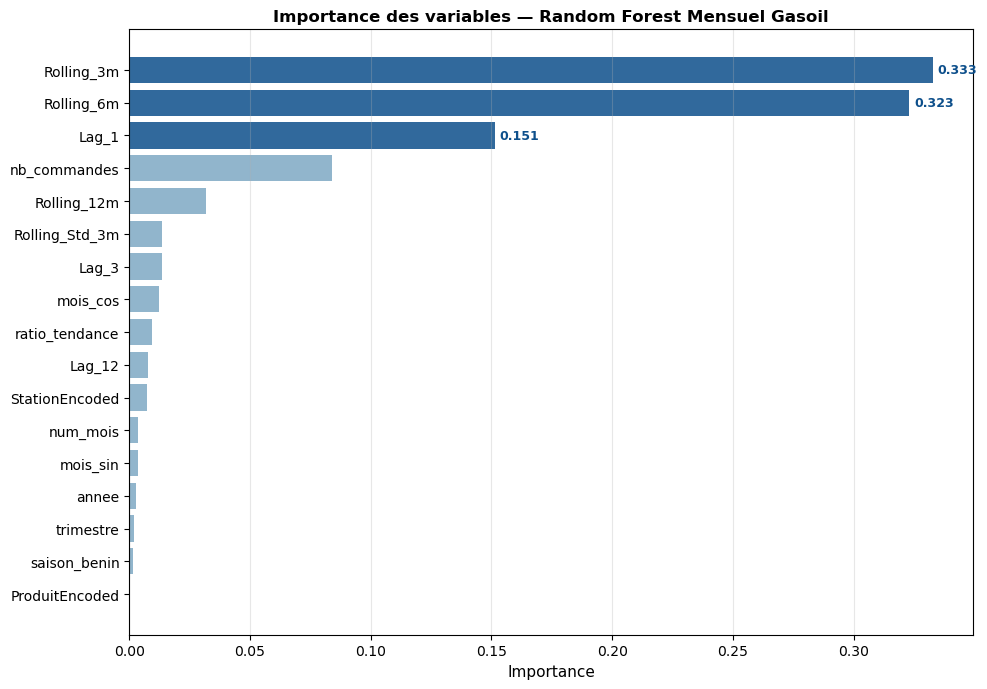

In [27]:
# IMPORTANCE DES VARIABLES

importance = pd.DataFrame({
    'Variable'  : FEATURES,
    'Importance': rf_model_gas.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top features :")
display(importance)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#0D4F8B' if i < 3 else '#7EA8C4' for i in range(len(importance))]
ax.barh(importance['Variable'][::-1], importance['Importance'][::-1],
        color=colors[::-1], alpha=0.85)

ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Importance des variables — Random Forest Mensuel Gasoil', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Annoter les 3 premières
for i, (v, imp) in enumerate(zip(importance['Variable'][:3], importance['Importance'][:3])):
    rank = len(importance) - 1 - importance.index[importance['Variable'] == v].tolist()[0]
    ax.text(imp + 0.002, rank, f'{imp:.3f}', va='center', fontsize=9, color='#0D4F8B', fontweight='bold')

plt.tight_layout()
plt.savefig('rf_importance_mensuel_gas.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Analyse graphique : Réel vs Prédit

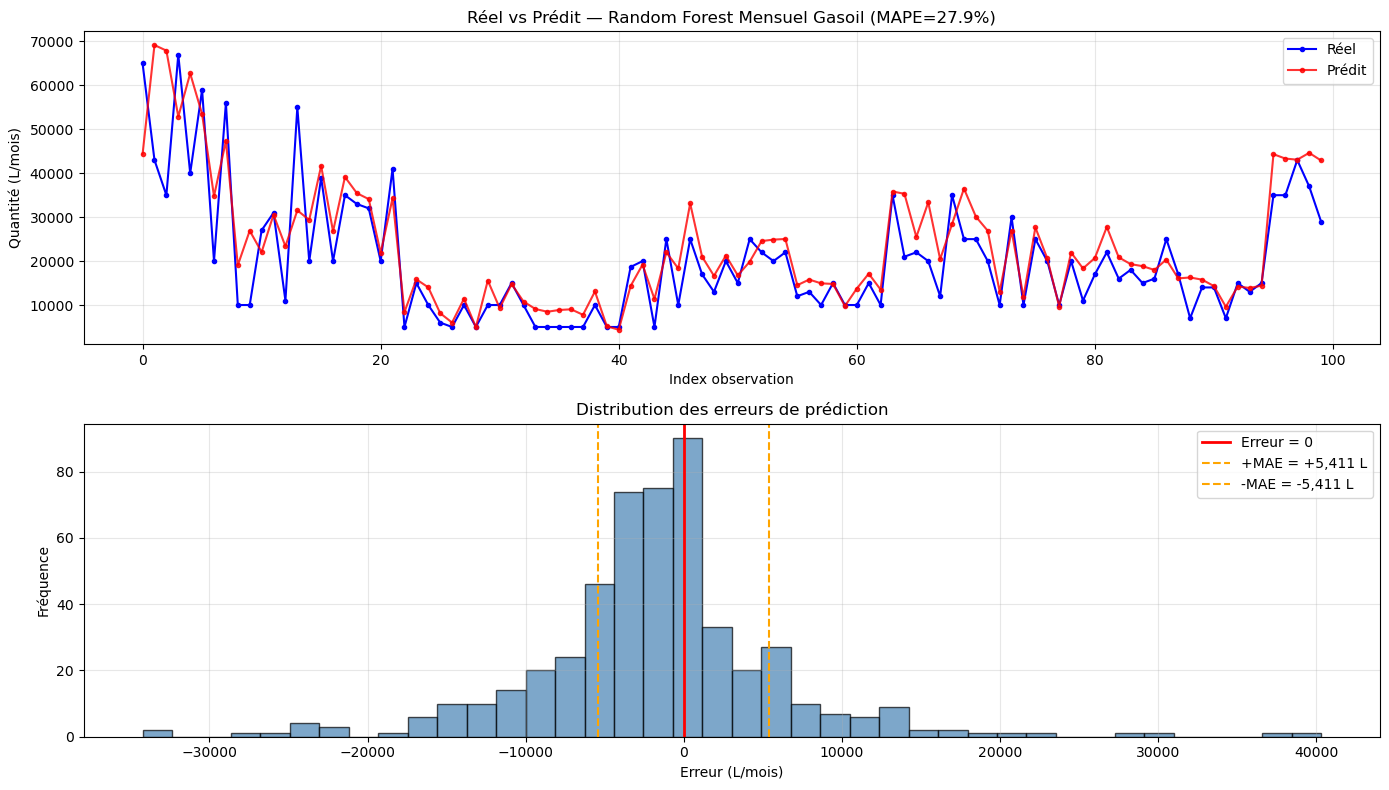

In [33]:
# VISUALISATION RÉEL VS PRÉDIT (100 premiers points)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Graphique 1 : courbes réel vs prédit
axes[0].plot(y_test.values[:100], 'b-o', label='Réel', markersize=3, linewidth=1.5)
axes[0].plot(y_pred[:100],        'r-o', label='Prédit', markersize=3, linewidth=1.5, alpha=0.8)
axes[0].set_title(f'Réel vs Prédit — Random Forest Mensuel Gasoil (MAPE={mape_rf_gas:.1f}%)', fontsize=12)
axes[0].set_xlabel('Index observation')
axes[0].set_ylabel('Quantité (L/mois)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : distribution des erreurs
errors = y_test.values - y_pred
axes[1].hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linewidth=2, label='Erreur = 0')
axes[1].axvline(mae_rf_gas,  color='orange', linestyle='--', label=f'+MAE = +{mae_rf_gas:,.0f} L')
axes[1].axvline(-mae_rf_gas, color='orange', linestyle='--', label=f'-MAE = -{mae_rf_gas:,.0f} L')
axes[1].set_title('Distribution des erreurs de prédiction', fontsize=12)
axes[1].set_xlabel('Erreur (L/mois)')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_prediction_mensuel_gas.png', dpi=120, bbox_inches='tight')
plt.show()


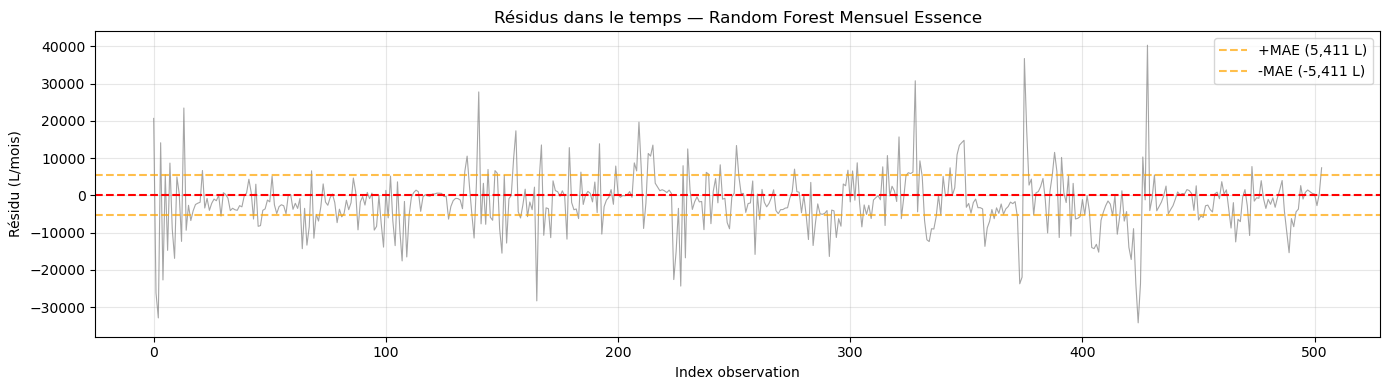

Test Jarque-Bera (normalité des résidus) : p-value = 0.0000
 Résidus non normalement distribués


In [35]:
# ANALYSE DES RÉSIDUS DANS LE TEMPS

residus = y_test.values - y_pred

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(residus, color='gray', alpha=0.7, linewidth=0.8)
ax.axhline(y=0,      color='red',    linestyle='--', linewidth=1.5)
ax.axhline(y=mae_rf_gas,  color='orange', linestyle='--', alpha=0.7, label=f'+MAE ({mae_rf_gas:,.0f} L)')
ax.axhline(y=-mae_rf_gas, color='orange', linestyle='--', alpha=0.7, label=f'-MAE (-{mae_rf_gas:,.0f} L)')
ax.set_title('Résidus dans le temps — Random Forest Mensuel Essence', fontsize=12)
ax.set_xlabel('Index observation')
ax.set_ylabel('Résidu (L/mois)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Test de normalité des résidus
from scipy import stats
jb_stat, jb_pvalue = stats.jarque_bera(residus)
print(f"Test Jarque-Bera (normalité des résidus) : p-value = {jb_pvalue:.4f}")
if jb_pvalue > 0.05:
    print(" Résidus normalement distribués")
else:
    print(" Résidus non normalement distribués")


**Analyse graphique : Réel vs Prédit et résidus**
On visualise les prédictions face aux valeurs réelles (100 premiers points) et on analyse les résidus (différence réel – prédit) pour détecter d’éventuels biais ou hétéroscédasticité.

*"Le graphique réel vs prédit montre que le modèle suit globalement la tendance générale, mais sous-estime certains pics de consommation. L’analyse des résidus révèle une concentration autour de zéro, avec quelques erreurs extrêmes. Le test de Jarque‑Bera indique que les résidus ne sont pas normalement distribués (p‑valeur < 0,05), ce qui est attendu sur des données de consommation réelles."*

Ces diagnostics graphiques sont essentiels pour valider la pertinence du modèle. La non-normalité des résidus n’est pas bloquante pour un modèle de prédiction (Random Forest n’exige pas la normalité), mais mérite d’être mentionnée.

## 11. Analyse des erreurs par station

In [38]:
# ERREUR PAR STATION — identifier les stations difficiles à prédire

df_test_res = df_test.copy()
df_test_res['Prédit']   = y_pred
df_test_res['Réel']     = y_test.values
df_test_res['Erreur']   = abs(df_test_res['Réel'] - df_test_res['Prédit'])

resultats_stations = []

for station in df_test_res['Code Station'].unique():
    mask = df_test_res['Code Station'] == station
    if mask.sum() < 3:
        continue

    reels   = df_test_res.loc[mask, 'Réel']
    predits = df_test_res.loc[mask, 'Prédit']

    mape_st = mean_absolute_percentage_error(reels, predits) * 100
    mae_st  = mean_absolute_error(reels, predits)
    vol_moy = reels.mean()
    cv_st   = reels.std() / reels.mean() if reels.mean() > 0 else 0

    resultats_stations.append({
        'Code Station' : station,
        'MAPE (%)'     : round(mape_st, 1),
        'MAE (L)'      : round(mae_st, 0),
        'Vol. moy. (L)': round(vol_moy, 0),
        'CV'           : round(cv_st, 3),
        'Nb mois'      : mask.sum()
    })

df_erreurs = (
    pd.DataFrame(resultats_stations)
    .sort_values('MAPE (%)', ascending=False)
    .reset_index(drop=True)
)

print("Top 10 stations les plus difficiles à prédire :")
display(df_erreurs.head(10))
print()
print("Top 10 stations les mieux prédites :")
display(df_erreurs.tail(10))


Top 10 stations les plus difficiles à prédire :


,Code Station,MAPE (%),MAE (L),Vol. moy. (L),CV,Nb mois
0,ST0072,88.2,7573.0,8625.0,0.511,8
1,ST0002,68.7,10933.0,23429.0,0.696,7
2,ST0058,59.3,8479.0,19500.0,0.607,8
3,ST0055,54.3,3379.0,6375.0,0.355,8
4,ST0069,53.7,5363.0,11875.0,0.401,8
5,ST0009,51.8,5321.0,17000.0,0.534,5
6,ST0001,45.4,18192.0,48125.0,0.340,8
7,ST0080,43.9,4019.0,10500.0,0.292,8
8,ST0087,41.8,6900.0,18625.0,0.388,8
9,ST0065,40.5,3328.0,8571.0,0.176,7



Top 10 stations les mieux prédites :


,Code Station,MAPE (%),MAE (L),Vol. moy. (L),CV,Nb mois
59,ST0029,14.3,5828.0,42500.0,0.198,8
60,ST0030,13.6,3491.0,22500.0,0.336,8
61,ST0003,13.2,3813.0,31429.0,0.268,7
62,ST0038,12.6,1399.0,11000.0,0.270,6
63,ST0084,8.6,3645.0,43875.0,0.167,8
64,ST0028,8.5,933.0,11250.0,0.222,4
65,ST0019,7.8,409.0,5625.0,0.314,8
66,ST0081,6.4,1454.0,22200.0,0.210,5
67,ST0032,5.9,394.0,6429.0,0.380,7
68,ST0078,5.1,765.0,15000.0,0.000,5



**Analyse des erreurs par station**  
On agrège les erreurs par station pour identifier celles qui sont les plus difficiles à prédire (MAPE élevé) et celles qui sont bien modélisées. On calcule aussi le coefficient de variation (CV) pour voir si la difficulté est liée à la variabilité naturelle.

L’analyse par station montre que certaines stations présentent un MAPE supérieur à 50 %, lié à une forte variabilité (CV élevé) ou à un faible volume moyen. À l’inverse, les stations les mieux prédites (MAPE < 15 %) affichent des séries plus régulières. Cette distinction suggère qu’un modèle unique peut être insuffisant pour les stations très volatiles et qu’une approche par cluster ou un modèle par station pourrait être explorée.

## 12. Sauvegarde du modèle

In [42]:
# SAUVEGARDE DU MODÈLE ET DES RÉSULTATS

joblib.dump(rf_model_gas, 'random_forest_mensuel_gasoil.pkl')
print("Modèle sauvegardé : random_forest_mensuel_gasoil.pkl")

# Sauvegarder les métriques pour comparaison ultérieure
metriques_rf = {
    'modele'    : 'Random Forest Mensuel gasoil',
    'mae'       : round(mae_rf_gas, 2),
    'rmse'      : round(rmse_rf_gas, 2),
    'mape'      : round(mape_rf_gas, 2),
    'r2'        : round(r2_rf_gas, 4),
}
pd.DataFrame([metriques_rf]).to_csv('metriques_rf_mensuel_gas.csv', index=False)
print("Métriques sauvegardées : metriques_rf_mensuel_gas.csv")
print()
print(metriques_rf)


Modèle sauvegardé : random_forest_mensuel_gasoil.pkl
Métriques sauvegardées : metriques_rf_mensuel_gas.csv

{'modele': 'Random Forest Mensuel gasoil', 'mae': 5410.54, 'rmse': 8002.31, 'mape': 27.87, 'r2': 0.7879}
